In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from itertools import cycle, islice
import random 
from pylab import *
from matplotlib.ticker import StrMethodFormatter
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import csv
import sys, subprocess, glob, os, shutil, re, importlib, Bio
from subprocess import call
from Bio import SeqIO
from scipy import stats
from scipy.integrate import quad
import seaborn as sns
import os
import seaborn as sns; sns.set()
from matplotlib import pyplot
from functools import reduce
import matplotlib as mpl
from matplotlib import gridspec
import itertools
import matplotlib.patches as mpatches
import random 
from pylab import *
from matplotlib.font_manager import FontProperties 
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
from matplotlib import gridspec

In [2]:
# define functions 

def integrate_over_bins(lower_bound,upper_bound):
    # generate lambda function for 1/x
    f= lambda x:(1/x)

    # integrate between bins 
    integral = quad(f, lower_bound, upper_bound)[0]
    return(integral)

def return_area_under_curve(bins):

    total_area_under_curve = 0
    integrals = []
    
    for i in range(len(bins)-1):
        lower_bound = bins[i]
        upper_bound = bins[i+1]
        integral = integrate_over_bins(lower_bound,upper_bound)
        integrals.append(integral)
        
    total_area_under_curve = np.asarray(integrals).sum()
    return(total_area_under_curve, integrals)

def return_neutral_expectation(total_area_under_curve, integrals):
    proportions = []
    for i in integrals: 
        proportion = i/total_area_under_curve
        proportions.append(proportion)
        
    return(proportions)

In [3]:
# predict neutral expectations for 10 bins 
bins = [0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.99]
total_area_under_curve, integrals = return_area_under_curve(bins)
proportions = return_neutral_expectation(total_area_under_curve, integrals)
neutral_df = pd.DataFrame({"bin":["1-10%","10-20%","20-30%","30-40%","40-50%","50-60%","60-70%","70-80%","80-90%","90-99%"],"expected":proportions})
# neutral_df.set_index('bin', inplace=True)
neutral_df.rename(columns={'expected':'proportion'}, inplace=True)

In [4]:
neutral_df

,bin,proportion
0,1-10%,0.501094
1,10-20%,0.150844
2,20-30%,0.088238
3,30-40%,0.062606
4,40-50%,0.048561
5,50-60%,0.039677
6,60-70%,0.033547
7,70-80%,0.029059
8,80-90%,0.025632
9,90-99%,0.020742


In [5]:
# Define the set of values you're interested in
subset_values = ['1-10%', '10-20%', '20-30%', '30-40%', '40-50%']

# Filter the DataFrame using `isin()`
# avg_bins50 = avg_bins[avg_bins['bin'].isin(subset_values)]
neutral50 = neutral_df[neutral_df['bin'].isin(subset_values)]

In [7]:
neutral50

,bin,proportion
0,1-10%,0.501094
1,10-20%,0.150844
2,20-30%,0.088238
3,30-40%,0.062606
4,40-50%,0.048561


In [10]:
df = pd.read_csv('../../hpai-comm-pa/output_dfs/2026-05-21_repshared_SNVs_allcom_lbm_2pct.tsv', sep='\t')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   segment               307 non-null    object 
 1   position              307 non-null    int64  
 2   allele                307 non-null    object 
 3   coding_region_change  307 non-null    object 
 4   gene                  259 non-null    object 
 5   Frequency_1           307 non-null    float64
 6   Frequency_2           307 non-null    float64
 7   sample                307 non-null    object 
 8   amino_acid            307 non-null    int64  
 9   gene_pos              307 non-null    object 
 10  sample_var            307 non-null    object 
 11  syn_non               307 non-null    object 
 12  sample_ID             307 non-null    object 
 13  domestic_status       307 non-null    object 
 14  ct_value              307 non-null    float64
 15  rep_shared            3

In [11]:
df.head(5)

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,order,county,date,species,species_group,color,avg_freq,order_domstat,gene_pos_nt,genotype
0,na,43,T,Ile8Thr,NaN,0.3326,0.3412,c_com5,8,NA_8,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial,NA_43,D1.1
1,na,67,T,Val16Ala,NaN,0.2439,0.2890,c_com5,16,NA_16,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.26645,galliformes_commercial,NA_67,D1.1
2,na,76,T,Ile19Thr,NaN,0.2454,0.2615,c_com5,19,NA_19,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25345,galliformes_commercial,NA_76,D1.1
3,na,79,T,Ile20Thr,NaN,0.2392,0.2624,c_com5,20,NA_20,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25080,galliformes_commercial,NA_79,D1.1
4,pa,1173,C,Asp383Asp,PA,0.1338,0.1468,c_com5,383,PA_383,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_synonymous,0.14030,galliformes_commercial,PA_1173,D1.1


In [13]:

# # ---- 1. Define bins ----
# bin_edges  = [0.01, 0.10, 0.20, 0.30, 0.40, 0.50]     # use 1, 10, 20... if var_freq is in percent
# bin_labels = ['1-10%', '10-20%', '20-30%', '30-40%', '40-50%']

# # ---- 2. Label each variant ----
# df = df.copy()
# df['bin'] = pd.cut(df['avg_freq'], bins=bin_edges, labels=bin_labels, include_lowest=True)
# df['snv_class'] = np.where(df['syn_non'].astype(bool), 'nonsynonymous', 'synonymous')

# # drop variants outside 1-50%
# df = df.dropna(subset=['bin'])

# # ---- 3. Counts per sample x class x bin ----
# counts = (df.groupby(['sample', 'snv_class', 'bin'], observed=False)
#             .size()
#             .unstack('bin', fill_value=0))

# # ---- 4. Convert to proportions (each sample/class sums to 1 across bins) ----
# props = counts.div(counts.sum(axis=1), axis=0)

# # ---- 5. Mean and std across samples ----
# mean_by_class = props.groupby('snv_class').mean()
# std_by_class  = props.groupby('snv_class').std()

# avg_bins50 = pd.DataFrame({
#     'bin':         bin_labels,
#     'mean_syn':    mean_by_class.loc['synonymous'].values,
#     'std_syn':     std_by_class.loc['synonymous'].values,
#     'mean_nonsyn': mean_by_class.loc['nonsynonymous'].values,
#     'std_nonsyn':  std_by_class.loc['nonsynonymous'].values,
# })

# print(avg_bins50)
# print(neutral50)

KeyError: 'synonymous'

In [16]:
# ---- 1. Define bins ----
bin_edges  = [0.01, 0.10, 0.20, 0.30, 0.40, 0.50]     # use [1, 10, 20, 30, 40, 50] if avg_freq is in percent
bin_labels = ['1-10%', '10-20%', '20-30%', '30-40%', '40-50%']

# ---- 2. Label each variant ----
df = df.copy()
df['bin'] = pd.cut(df['avg_freq'], bins=bin_edges, labels=bin_labels, include_lowest=True)

# use the strings directly (no astype(bool))
df['snv_class'] = df['syn_non'].astype(str).str.strip().str.lower()

print(df['snv_class'].value_counts())   # should show both 'synonymous' and 'nonsynonymous'

# keep only the two classes and variants within 1-50%
df = df[df['snv_class'].isin(['synonymous', 'nonsynonymous'])]
df = df.dropna(subset=['bin'])

# ---- 3. Counts per sample x class x bin ----
counts = (df.groupby(['sample', 'snv_class', 'bin'], observed=False)
            .size()
            .unstack('bin', fill_value=0))

# ---- 4. Convert to proportions (each sample/class sums to 1 across bins) ----
props = counts.div(counts.sum(axis=1), axis=0)

# ---- 5. Mean and std across samples ----
classes = ['synonymous', 'nonsynonymous']
mean_by_class = props.groupby('snv_class').mean().reindex(classes)
std_by_class  = props.groupby('snv_class').std().reindex(classes)

avg_bins50 = pd.DataFrame({
    'bin':         bin_labels,
    'mean_syn':    mean_by_class.loc['synonymous'].values,
    'std_syn':     std_by_class.loc['synonymous'].values,
    'mean_nonsyn': mean_by_class.loc['nonsynonymous'].values,
    'std_nonsyn':  std_by_class.loc['nonsynonymous'].values,
})

print(avg_bins50)
print(neutral50)

snv_class
synonymous       188
nonsynonymous    119
Name: count, dtype: int64
      bin  mean_syn   std_syn  mean_nonsyn  std_nonsyn
0   1-10%  0.512141  0.352783     0.459370    0.339143
1  10-20%  0.218985  0.255104     0.209447    0.266750
2  20-30%  0.103639  0.166650     0.127419    0.205144
3  30-40%  0.099515  0.211452     0.138172    0.246050
4  40-50%  0.065720  0.136255     0.065591    0.205568
      bin  proportion
0   1-10%    0.501094
1  10-20%    0.150844
2  20-30%    0.088238
3  30-40%    0.062606
4  40-50%    0.048561


In [17]:
avg_bins50

,bin,mean_syn,std_syn,mean_nonsyn,std_nonsyn
0,1-10%,0.512141,0.352783,0.459370,0.339143
1,10-20%,0.218985,0.255104,0.209447,0.266750
2,20-30%,0.103639,0.166650,0.127419,0.205144
3,30-40%,0.099515,0.211452,0.138172,0.246050
4,40-50%,0.065720,0.136255,0.065591,0.205568


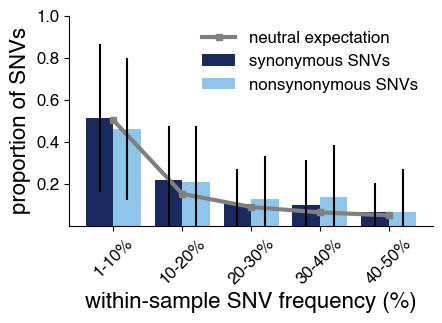

In [33]:
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text', usetex='false') 
# plt.rcParams.update({'font.size': 22})


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "text.usetex": False
})
##plot binned frequency proportions by synonymous vs. nonsynonymous all samples

# Define bar width and position offset
bar_width = 0.4  # Width of bars
bin_positions = np.arange(len(avg_bins50['bin']))  # Get numeric positions for bins

# # Generate figure
fig = plt.figure(figsize=(8,6), facecolor='w')

ax1 = fig.add_subplot(gs[0,0:3])

# Remove top and right frame
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)

# Set fontsize of axes
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.tick_params(axis='both', which='minor', labelsize=12)

# Plot neutral expectation as a line
neutral50.plot(kind='line', grid=False, color='grey', alpha=1, linewidth=3, marker="s", markersize=5, ax=ax1, label="neutral expectation")

# Plot synonymous and nonsynonymous bars side by side
ax1.bar(bin_positions - bar_width/2, avg_bins50['mean_syn'], yerr=avg_bins50['std_syn'],
        color='#1B2A5E', ecolor='black', alpha=1, width=bar_width, label="synonymous SNVs")      # navy

ax1.bar(bin_positions + bar_width/2, avg_bins50['mean_nonsyn'], yerr=avg_bins50['std_nonsyn'],
        color='#8EC5E8', ecolor='black', alpha=1, width=bar_width, label="nonsynonymous SNVs")   # light blue

# # Formatting
# ax1.set_facecolor('white')
# for tick in ax1.get_xticklabels():
#     tick.set_fontname("Arial")
# for tick in ax1.get_yticklabels():
#     tick.set_fontname("Arial")

ax1.set_ylim(0, 1.0)
ax1.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0 ])
ax1.set_ylabel('proportion of SNVs',fontsize=16)
ax1.set_xlabel('within-sample SNV frequency (%)', fontsize=16)
ax1.set_xticks(bin_positions)
ax1.set_xticklabels(['1-10%', '10-20%', '20-30%', '30-40%', '40-50%'], 
                    minor=False, rotation=45)


# Get the legend handles and labels
handles, labels = ax1.get_legend_handles_labels()

# Modify only the neutral expectation label
labels[0] = "neutral expectation"  # Assuming neutral_df is the first plotted dataset

# Update the legend with the modified labels
ax1.legend(handles, labels, loc=0, frameon=False, ncol=1, fontsize=12)

# ax1.set_title('avg proportion of SNVs by frequency for fox samples (with std dev)', fontsize=16)
plt.savefig("../../hpai-comm-pa/output_plots/snvs_frequency_binned.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()
